# Crossformer — Multivariate Electricity Consumption Forecasting

*Mirrors the previous (working) Crossformer pipeline; only the loss is changed to `money_pct + 0.2*SMAPE`.*

In [1]:
import warnings, os, math, time, json, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple, Dict
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
import mlflow

from data_loading import *
from loss_funcs import *

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
print(f"Device           : {DEVICE}")


PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
Device           : cuda


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  — mirrors previous (working) Crossformer run hyperparameters
# Only change vs that run: the loss is money_pct + 0.2*SMAPE instead of RMSE.
# ══════════════════════════════════════════════════════════════════════════════

# ── Feature columns (D_IN = 15: target + 6 weather + 2 static + 6 cyclical) ──
WEATHER_FEATS = [
    "temperature_2m", "dew_point_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m", "shortwave_radiation",
]
weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]
STATIC_FEATS_REAL = ["latitude", "longitude"]
TIME_FEATS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

# Target FIRST so RevIN denormalization in the model uses index 0.
INPUT_FEATURES = [Y_COL] + WEATHER_FEATS + STATIC_FEATS_REAL + TIME_FEATS
D_IN = len(INPUT_FEATURES)   # 1 + 6 + 2 + 6 = 15

# Prices used by the loss but NOT fed to the model.
PRICE_COLS = ["dam_price", "sell_bm_price", "buy_bm_price"]

# ── Sequence ──────────────────────────────────────────────────────────────────
SEQ_LEN  = 168     # 1-week lookback
PRED_LEN = 48      # 48-hour forecast
SEG_LEN  = 12      # 168/12 = 14 input segments, 48/12 = 4 output segments

# ── Model ─────────────────────────────────────────────────────────────────────
D_MODEL  = 256
N_HEADS  = 4
E_LAYERS = 3
D_FF     = 512
DROPOUT  = 0.1
WIN_SIZE = 2

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 256
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-2     # strong WD -- key to prior run's generalization
MAX_EPOCHS    = 30
PATIENCE      = 5
TRAIN_STRIDE  = 6        # subsample windows for diversity vs speed

# Loss mixing: money_pct is the business objective, SMAPE provides a smooth,
# scale-free regularizer.
SMAPE_WEIGHT = 0.2

NUM_WORKERS = 0
CKPT_PATH   = "crossformer_best.pt"

print(f"Input features (D_IN={D_IN}):", INPUT_FEATURES)


Input features (D_IN=15): ['sum_of_kWh', 'temperature_2m', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [3]:
def add_cyclical_time_features(df):
    """sin/cos pairs from the datetime column, bounded in [-1, 1]."""
    dt = pd.to_datetime(df["datetime"])
    df["hour_sin"]  = np.sin(2 * np.pi * dt.dt.hour      / 24).astype("float32")
    df["hour_cos"]  = np.cos(2 * np.pi * dt.dt.hour      / 24).astype("float32")
    df["dow_sin"]   = np.sin(2 * np.pi * dt.dt.dayofweek / 7 ).astype("float32")
    df["dow_cos"]   = np.cos(2 * np.pi * dt.dt.dayofweek / 7 ).astype("float32")
    df["month_sin"] = np.sin(2 * np.pi * dt.dt.month     / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * dt.dt.month     / 12).astype("float32")
    return df


In [4]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)
print(f"val: {val.shape}  range: {val['datetime'].min()} → {val['datetime'].max()}")

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)
print(f"test: {test.shape}  range: {test['datetime'].min()} → {test['datetime'].max()}")


Loading train …
train: (4586151, 38)  range: 2024-01-01 01:00:00+02:00 → 2025-06-30 23:00:00+03:00
Loading val   …
val: (293880, 38)  range: 2025-07-01 00:00:00+03:00 → 2025-07-31 23:00:00+03:00
Loading test  …
test: (295430, 38)  range: 2025-08-01 00:00:00+03:00 → 2025-09-01 03:00:00+03:00


In [5]:
# # Optional station sub-sampling (kept off by default — uncomment to use).
# TARGET_STATIONS = 409
# np.random.seed(42)
# station_stats = (
#     train.groupby(GROUP_COL)
#     .agg(rows=(Y_COL, "count")).reset_index()
#     .sort_values("rows", ascending=False)
# )
# sampled_stations = station_stats.sample(n=TARGET_STATIONS, random_state=42)[GROUP_COL].values
# print(f"Stations: {len(sampled_stations)}")
# train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# val   = val  [val  [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# test  = test [test [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

# ── Build unified all_data (mirrors previous notebook) ────────────────────────
# Concatenate splits, rebuild a single continuous time_idx across the whole
# span. This is what makes "train+val context for val inference" work cleanly.
train["data_subset"] = "train"
val  ["data_subset"] = "val"
test ["data_subset"] = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

all_data["datetime"] = pd.to_datetime(all_data["datetime"], utc=True, errors="coerce")
all_data["datetime"] = all_data["datetime"].dt.tz_convert(None)
all_data["time_idx"] = (
    (all_data["datetime"] - all_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

# Add cyclical time features BEFORE slicing into splits
all_data = add_cyclical_time_features(all_data)

# Drop weather columns that the model doesn't use (matches previous notebook)
drop_cols = [c for c in weather_cols_to_drop if c in all_data.columns]
if drop_cols:
    all_data.drop(columns=drop_cols, inplace=True)

# Cutoffs (used by predict_split below)
training_cutoff = all_data.loc[all_data["data_subset"] == "train", "time_idx"].max()
val_cutoff      = all_data.loc[all_data["data_subset"] == "val",   "time_idx"].max()
test_cutoff     = all_data.loc[all_data["data_subset"] == "test",  "time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

# Verify expected features exist
missing = [f for f in INPUT_FEATURES + PRICE_COLS if f not in all_data.columns]
if missing:
    print(f"WARNING — missing features: {missing}")
else:
    print(f"All {D_IN} input features + 3 price columns present")


training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617
All 15 input features + 3 price columns present


In [6]:
class CrossformerDataset(Dataset):
    """
    Lazy sliding-window dataset for Crossformer (verbatim from the previous
    project's CrossformerDataset). A parallel `prices` block is added so the
    money loss can read prices for the future window without leaking them
    into the model input.

    Each sample:
        x      : (seq_len, D_IN)        target at index 0, then weather/static/cyclical
        y      : (pred_len,)            future target (raw kWh)
        prices : (pred_len, 3)          dam_price, sell_bm_price, buy_bm_price
    """
    def __init__(self, df, group_col, target_col, feature_cols, price_cols,
                 seq_len, pred_len, stride=1):
        self.seq_len, self.pred_len = seq_len, pred_len
        assert feature_cols[0] == target_col, "target_col must be feature 0"

        self._feat: List[np.ndarray] = []
        self._prc:  List[np.ndarray] = []
        self._index: List[Tuple[int, int]] = []

        for _, gdf in tqdm(
            df.groupby(group_col, sort=False),
            desc="Building dataset index", leave=False,
        ):
            gdf = gdf.sort_values("time_idx")
            feat = gdf[feature_cols].values.astype(np.float32)
            prc  = gdf[price_cols].values.astype(np.float32)
            g_idx = len(self._feat)
            self._feat.append(feat)
            self._prc.append(prc)
            n = len(feat)
            for s in range(0, n - seq_len - pred_len + 1, stride):
                self._index.append((g_idx, s))

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        g, s = self._index[idx]
        feat = self._feat[g]
        prc  = self._prc[g]
        e_in  = s + self.seq_len
        e_out = e_in + self.pred_len
        x      = torch.from_numpy(feat[s:e_in].copy())
        y      = torch.from_numpy(feat[e_in:e_out, 0].copy())
        prices = torch.from_numpy(prc[e_in:e_out].copy())
        return x, y, prices


# ── Per-split dataframe views (mirrors previous notebook) ─────────────────────
# train_df: only train rows
# val_df:   train + val rows (model needs SEQ_LEN of history before first val step)
# test_df:  full all_data
train_mask = all_data["data_subset"] == "train"
val_mask   = all_data["data_subset"].isin(["train", "val"])

train_df = all_data[train_mask].copy()
val_df   = all_data[val_mask].copy()
test_df  = all_data.copy()
all_data.drop(columns=["data_subset"], inplace=True)

print(f"train_df rows : {len(train_df):,}")
print(f"val_df   rows : {len(val_df):,}  (includes train history)")
print(f"test_df  rows : {len(test_df):,}  (includes train+val history)")

print("\nBuilding train dataset …")
train_ds = CrossformerDataset(
    train_df, GROUP_COL, Y_COL, INPUT_FEATURES, PRICE_COLS,
    SEQ_LEN, PRED_LEN, stride=TRAIN_STRIDE,
)
print(f"  → {len(train_ds):,} samples")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)


train_df rows : 4,586,151
val_df   rows : 4,880,031  (includes train history)
test_df  rows : 5,175,461  (includes train+val history)

Building train dataset …


Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

  → 750,394 samples


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSSFORMER MODEL (verbatim port of previous notebook).
# Per-sample RevIN-style instance normalization inside forward() is the key
# to robust generalization across stations with very different magnitudes.
# ══════════════════════════════════════════════════════════════════════════════

class DSW_Embedding(nn.Module):
    """Dimension-Segment-Wise embedding: (B, T, D) -> (B, D, num_seg, d_model)."""
    def __init__(self, seg_len: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.seg_len = seg_len
        self.proj = nn.Linear(seg_len, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        pad = (self.seg_len - T % self.seg_len) % self.seg_len
        if pad:
            x = F.pad(x, (0, 0, pad, 0))   # left-pad along time
        num_seg = x.shape[1] // self.seg_len
        x = x.reshape(B, num_seg, self.seg_len, D).permute(0, 3, 1, 2)
        return self.drop(self.proj(x))


class TwoStageAttentionLayer(nn.Module):
    """Cross-Time then Cross-Dimension attention. (B, D, L, d_model) in/out."""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ct_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ct_norm1 = nn.LayerNorm(d_model)
        self.ct_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ct_norm2 = nn.LayerNorm(d_model)
        self.cd_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cd_norm1 = nn.LayerNorm(d_model)
        self.cd_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.cd_norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, D, L, d = x.shape
        # Cross-Time
        xt = x.reshape(B * D, L, d)
        out, _ = self.ct_attn(xt, xt, xt)
        xt = self.ct_norm1(xt + self.drop(out))
        xt = self.ct_norm2(xt + self.ct_ff(xt))
        x  = xt.reshape(B, D, L, d)
        # Cross-Dimension
        xd = x.permute(0, 2, 1, 3).reshape(B * L, D, d)
        out, _ = self.cd_attn(xd, xd, xd)
        xd = self.cd_norm1(xd + self.drop(out))
        xd = self.cd_norm2(xd + self.cd_ff(xd))
        x  = xd.reshape(B, L, D, d).permute(0, 2, 1, 3)
        return x


class SegMerging(nn.Module):
    """Halve the segment axis by concatenating adjacent segments."""
    def __init__(self, d_model: int, win_size: int = 2):
        super().__init__()
        self.win = win_size
        self.norm = nn.LayerNorm(d_model * win_size)
        self.proj = nn.Linear(d_model * win_size, d_model)

    def forward(self, x):
        B, D, L, d = x.shape
        if L % self.win:
            x = F.pad(x, (0, 0, 0, self.win - L % self.win))
            L = x.shape[2]
        x = x.reshape(B, D, L // self.win, self.win * d)
        return self.proj(self.norm(x))


class CrossformerEncoder(nn.Module):
    """Hierarchical encoder; returns finest -> coarsest level outputs."""
    def __init__(self, attn_layers, merge_layers):
        super().__init__()
        self.attn = attn_layers
        self.merge = merge_layers

    def forward(self, x):
        outs = []
        for i, layer in enumerate(self.attn):
            x = layer(x)
            outs.append(x)
            if i < len(self.merge):
                x = self.merge[i](x)
        return outs


class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_norm  = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ff_norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mem):
        B, D, Lq, d = x.shape
        _, _, Lk, _ = mem.shape
        xt = x.reshape(B * D, Lq, d)
        sa, _ = self.self_attn(xt, xt, xt)
        xt = self.self_norm(xt + self.drop(sa))
        mk = mem.reshape(B * D, Lk, d)
        ca, _ = self.cross_attn(xt, mk, mk)
        xt = self.cross_norm(xt + self.drop(ca))
        xt = self.ff_norm(xt + self.ff(xt))
        return xt.reshape(B, D, Lq, d)


class Crossformer(nn.Module):
    """Multivariate input (B,T,D) -> univariate target output (B, pred_len).
    Per-sample RevIN-style normalization inside forward()."""
    def __init__(self, seq_len, pred_len, seg_len, d_in,
                 d_model=256, n_heads=4, e_layers=3, d_ff=512,
                 dropout=0.1, win_size=2):
        super().__init__()
        self.pred_len = pred_len
        self.seg_len = seg_len
        self.embed = DSW_Embedding(seg_len, d_model, dropout)

        pad_in  = (seg_len - seq_len  % seg_len) % seg_len
        pad_out = (seg_len - pred_len % seg_len) % seg_len
        self.in_seg_num  = (seq_len  + pad_in)  // seg_len
        self.out_seg_num = (pred_len + pad_out) // seg_len

        self.enc_pos = nn.Parameter(torch.randn(1, 1, self.in_seg_num,  d_model) * 0.02)
        self.dec_pos = nn.Parameter(torch.randn(1, 1, self.out_seg_num, d_model) * 0.02)
        self.dim_pos = nn.Parameter(torch.randn(1, d_in, 1,             d_model) * 0.02)

        self.encoder = CrossformerEncoder(
            nn.ModuleList([TwoStageAttentionLayer(d_model, n_heads, d_ff, dropout)
                           for _ in range(e_layers)]),
            nn.ModuleList([SegMerging(d_model, win_size) for _ in range(e_layers - 1)]),
        )
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(e_layers)
        ])
        self.out_proj = nn.Linear(d_model, seg_len)

    def forward(self, x):
        B, T, D = x.shape
        # RevIN-style instance norm
        mu  = x.mean(dim=1, keepdim=True)
        sig = x.std (dim=1, keepdim=True).clamp(1e-5)
        x_n = (x - mu) / sig

        enc_in   = self.embed(x_n) + self.enc_pos + self.dim_pos
        enc_outs = self.encoder(enc_in)

        dec_q = (self.dec_pos + self.dim_pos).expand(B, -1, -1, -1)
        for dec_layer, mem in zip(self.dec_layers, reversed(enc_outs)):
            dec_q = dec_layer(dec_q, mem)

        out = self.out_proj(dec_q)
        out = out.reshape(B, D, -1)
        out = out[:, 0, :self.pred_len]               # target only
        out = out * sig[:, 0, 0:1] + mu[:, 0, 0:1]    # denormalize using target stats
        return out


# ── Instantiate & smoke-test ──────────────────────────────────────────────────
model = Crossformer(
    seq_len=SEQ_LEN, pred_len=PRED_LEN, seg_len=SEG_LEN, d_in=D_IN,
    d_model=D_MODEL, n_heads=N_HEADS, e_layers=E_LAYERS,
    d_ff=D_FF, dropout=DROPOUT, win_size=WIN_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Crossformer parameters : {n_params:,}")

with torch.no_grad():
    dummy = torch.randn(4, SEQ_LEN, D_IN).to(DEVICE)
    out = model(dummy)
    assert out.shape == (4, PRED_LEN), f"unexpected shape {out.shape}"
print(f"Forward OK: {tuple(dummy.shape)} -> {tuple(out.shape)}")


Crossformer parameters : 5,814,540
Forward OK: (4, 168, 15) -> (4, 48)


In [8]:
# ── Losses (torch, raw kWh space) ─────────────────────────────────────────────
# money_pct mirrors loss_funcs.money_pct (piecewise-linear, fully differentiable).
# SMAPE is computed on raw kWh -- never on z-scored values. Both are in % so they
# combine cleanly.

def money_pct_torch(y_true, y_pred, dam, sell, buy, eps=1e-6):
    p, sp, bp = dam / 1000.0, sell / 1000.0, buy / 1000.0
    min_spend = y_true * p
    ordered   = y_pred * p
    diff      = y_pred - y_true
    real_spend = (
        ordered
        - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
        - torch.where(diff < 0, bp * diff, torch.zeros_like(diff))
    )
    excess = real_spend - min_spend
    denom  = (min_spend.sum().abs() / 100.0) + eps
    return excess.sum() / denom


def smape_torch(y_true, y_pred, eps=1e-6):
    return 100.0 * torch.mean(
        2.0 * torch.abs(y_pred - y_true)
        / (torch.abs(y_pred) + torch.abs(y_true) + eps)
    )


def combined_loss(y_pred, y_true, prices, smape_weight=SMAPE_WEIGHT):
    """y_pred, y_true: (B, pred_len) raw kWh.  prices: (B, pred_len, 3)."""
    m = money_pct_torch(y_true, y_pred, prices[..., 0], prices[..., 1], prices[..., 2])
    s = smape_torch(y_true, y_pred)
    loss = m + smape_weight * s
    return loss, {"money_pct": float(m.detach()), "smape": float(s.detach())}


In [9]:
# ── Optimizer / scheduler / scaler ────────────────────────────────────────────
optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode="min", factor=0.5, patience=2)
scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


@torch.no_grad()
def evaluate_loss(df, stride: int = PRED_LEN) -> Dict[str, float]:
    """Rebuild a non-overlapping eval dataset (matches previous notebook),
    then return SMAPE and money_pct in % on raw kWh."""
    ds = CrossformerDataset(
        df, GROUP_COL, Y_COL, INPUT_FEATURES, PRICE_COLS,
        SEQ_LEN, PRED_LEN, stride=stride,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    model.eval()
    total_excess, total_min = 0.0, 0.0
    smape_sum, smape_n = 0.0, 0
    eps = 1e-6
    for xb, yb, pb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        pb = pb.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            pred = model(xb).float()

        p, sp, bp = pb[..., 0]/1000.0, pb[..., 1]/1000.0, pb[..., 2]/1000.0
        min_spend = yb * p
        ordered   = pred * p
        diff      = pred - yb
        real_spend = (ordered
                      - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
                      - torch.where(diff < 0, bp * diff, torch.zeros_like(diff)))
        total_excess += (real_spend - min_spend).sum().item()
        total_min    += min_spend.sum().item()

        s_elem = (2.0 * torch.abs(pred - yb)
                  / (torch.abs(pred) + torch.abs(yb) + eps))
        smape_sum += s_elem.sum().item()
        smape_n   += s_elem.numel()

    return {
        "money_pct": total_excess / (total_min / 100.0 + 1e-9),
        "smape":     100.0 * smape_sum / max(smape_n, 1),
    }


# ── MLflow run setup ──────────────────────────────────────────────────────────
mlflow.set_experiment("crossformer_money_smape")
mlflow.start_run(run_name=f"crossformer_{int(time.time())}")
mlflow.log_params({
    "seq_len": SEQ_LEN, "pred_len": PRED_LEN, "seg_len": SEG_LEN, "d_in": D_IN,
    "d_model": D_MODEL, "n_heads": N_HEADS, "e_layers": E_LAYERS, "d_ff": D_FF,
    "dropout": DROPOUT, "win_size": WIN_SIZE,
    "batch_size": BATCH_SIZE, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "train_stride": TRAIN_STRIDE,
    "smape_weight": SMAPE_WEIGHT, "n_params": n_params,
    "input_features": json.dumps(INPUT_FEATURES),
    "n_train_windows": len(train_ds),
})


# ── Training loop ─────────────────────────────────────────────────────────────
best_val_money = float("inf")
patience_count = 0
history = {"train_loss": [], "train_money": [], "train_smape": [],
           "val_money": [],   "val_smape": []}

print(f"Starting training — {MAX_EPOCHS} epochs on {DEVICE}")
print(f"  Steps / epoch : {len(train_loader):,}")
print(f"  Train samples : {len(train_ds):,}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss, ep_money, ep_smape, steps = 0.0, 0.0, 0.0, 0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{MAX_EPOCHS}", leave=False)
    for xb, yb, pb in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        pb = pb.to(DEVICE, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            pred = model(xb)
            loss, parts = combined_loss(pred.float(), yb, pb, smape_weight=SMAPE_WEIGHT)

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()

        epoch_loss += float(loss.detach())
        ep_money   += parts["money_pct"]
        ep_smape   += parts["smape"]
        steps += 1
        pbar.set_postfix(loss=f"{loss.item():.3f}",
                         m_pct=f"{parts['money_pct']:.2f}",
                         smape=f"{parts['smape']:.2f}")

    train_loss  = epoch_loss / steps
    train_money = ep_money   / steps
    train_smape = ep_smape   / steps
    val_metrics = evaluate_loss(val_df)
    scheduler.step(val_metrics["money_pct"])
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_money"].append(train_money)
    history["train_smape"].append(train_smape)
    history["val_money"].append(val_metrics["money_pct"])
    history["val_smape"].append(val_metrics["smape"])

    mlflow.log_metrics({
        "train_loss": train_loss,
        "train_money_pct": train_money,
        "train_smape": train_smape,
        "val_money_pct": val_metrics["money_pct"],
        "val_smape": val_metrics["smape"],
        "lr": optimiser.param_groups[0]["lr"],
    }, step=epoch)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train loss {train_loss:6.3f}  m_pct {train_money:5.2f}  smape {train_smape:5.2f} | "
        f"val m_pct {val_metrics['money_pct']:5.2f}  smape {val_metrics['smape']:5.2f} | "
        f"{elapsed:.0f}s"
    )

    if val_metrics["money_pct"] < best_val_money:
        best_val_money = val_metrics["money_pct"]
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  Checkpoint saved (val money_pct {best_val_money:.3f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

mlflow.log_metric("best_val_money_pct", best_val_money)
mlflow.log_artifact(CKPT_PATH)
print(f"\nBest val money_pct: {best_val_money:.3f}  —  {CKPT_PATH}")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("Best weights loaded.")


Starting training — 30 epochs on cuda
  Steps / epoch : 2,931
  Train samples : 750,394



Epoch 01/30:   0%|          | 0/2931 [00:00<?, ?it/s]

Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 01/30 | train loss  3.749  m_pct  2.35  smape  7.00 | val m_pct  1.87  smape  6.25 | 228s
  Checkpoint saved (val money_pct 1.874)


Epoch 02/30:   0%|          | 0/2931 [00:00<?, ?it/s]

...

Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 29/30 | train loss  1.371  m_pct  0.62  smape  3.75 | val m_pct  0.65  smape  3.86 | 227s


Epoch 30/30:   0%|          | 0/2931 [00:00<?, ?it/s]

Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

Epoch 30/30 | train loss  1.359  m_pct  0.61  smape  3.72 | val m_pct  0.65  smape  3.84 | 228s
  Checkpoint saved (val money_pct 0.651)

Best val money_pct: 0.651  —  crossformer_best.pt
Best weights loaded.


In [10]:
@torch.no_grad()
def predict_split(context_df, forecast_start: int, eval_cutoff: int, split_name: str = "split"):
    """
    Sliding-window inference over [forecast_start … eval_cutoff].

    Each PRED_LEN-hour block uses ground-truth context from the preceding
    SEQ_LEN hours (direct multi-step, no recursion).

    Returns DataFrame with [GROUP_COL, time_idx, datetime, Y_COL, pred,
    dam_price, sell_bm_price, buy_bm_price].
    """
    model.eval()
    rows = []
    feat_cols  = INPUT_FEATURES
    price_cols = PRICE_COLS

    for grp in tqdm(context_df[GROUP_COL].unique(), desc=f"Inferring {split_name}"):
        gdf = (context_df[context_df[GROUP_COL] == grp]
               .sort_values("time_idx").reset_index(drop=True))
        feat = gdf[feat_cols].values.astype(np.float32)
        prc  = gdf[price_cols].values.astype(np.float32)
        tidx = gdf["time_idx"].values
        dts  = gdf["datetime"].values
        tmap = {int(t): i for i, t in enumerate(tidx)}

        t = forecast_start
        while t <= eval_cutoff:
            ctx_start = t - SEQ_LEN
            if ctx_start not in tmap or t not in tmap:
                t += PRED_LEN; continue
            s = tmap[ctx_start]; e = tmap[t]
            if e - s != SEQ_LEN:
                t += PRED_LEN; continue

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
                xb = torch.from_numpy(feat[s:e].copy()).unsqueeze(0).to(DEVICE)
                pred = model(xb).squeeze(0).float().cpu().numpy()

            for step in range(PRED_LEN):
                ti = t + step
                if ti not in tmap: break
                pos = tmap[ti]
                rows.append({
                    GROUP_COL:       grp,
                    "time_idx":      int(ti),
                    "datetime":      dts[pos],
                    Y_COL:           float(feat[pos, 0]),
                    "pred":          float(pred[step]),
                    "dam_price":     float(prc[pos, 0]),
                    "sell_bm_price": float(prc[pos, 1]),
                    "buy_bm_price":  float(prc[pos, 2]),
                })
            t += PRED_LEN

    return pd.DataFrame(rows)


print("Running validation inference …")
val_eval  = predict_split(val_df,  training_cutoff + 1, val_cutoff, split_name="val")
print(f"  val_eval rows : {len(val_eval):,}")

print("Running test inference …")
test_eval = predict_split(test_df, val_cutoff + 1, test_cutoff, split_name="test")
print(f"  test_eval rows: {len(test_eval):,}")


Running validation inference …


Inferring val:   0%|          | 0/395 [00:00<?, ?it/s]

  val_eval rows : 293,880
Running test inference …


Inferring test:   0%|          | 0/395 [00:00<?, ?it/s]

  test_eval rows: 295,430


In [11]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

def bias(y_true, y_pred):
    return float(np.sum(np.asarray(y_pred, float) - np.asarray(y_true, float)))

# --- Validation ---
val_smape_v     = smape(val_eval[Y_COL], val_eval["pred"])
val_rmse_v      = rmse (val_eval[Y_COL], val_eval["pred"])
val_mape_v      = mape (val_eval[Y_COL], val_eval["pred"])
val_mae_v       = mae  (val_eval[Y_COL], val_eval["pred"])
val_bias_v      = bias (val_eval[Y_COL], val_eval["pred"])
val_money_v     = money    (val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))

# --- Test ---
test_smape_v     = smape(test_eval[Y_COL], test_eval["pred"])
test_rmse_v      = rmse (test_eval[Y_COL], test_eval["pred"])
test_mape_v      = mape (test_eval[Y_COL], test_eval["pred"])
test_mae_v       = mae  (test_eval[Y_COL], test_eval["pred"])
test_bias_v      = bias (test_eval[Y_COL], test_eval["pred"])
test_money_v     = money    (test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"MAE       : {val_mae_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"BIAS      : {val_bias_v:.4f}")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"MAE       : {test_mae_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"BIAS      : {test_bias_v:.4f}")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape": val_smape_v, "val_rmse": val_rmse_v, "val_mape": val_mape_v,
    "val_mae": val_mae_v, "val_bias": val_bias_v,
    "val_money": val_money_v, "val_money_pct": val_money_pct_v,
    "test_smape": test_smape_v, "test_rmse": test_rmse_v, "test_mape": test_mape_v,
    "test_mae": test_mae_v, "test_bias": test_bias_v,
    "test_money": test_money_v, "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")


── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
MAE       : 1.5275
RMSE      : 6.7145
MAPE      : 8.75 %
SMAPE     : 0.0661
BIAS      : -69485.1385
MONEY     : 845999.5795
MONEY_PCT : 2.8938%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
MAE       : 1.5243
RMSE      : 7.1376
MAPE      : 9.17 %
SMAPE     : 0.0613
BIAS      : 377.4421
MONEY     : 1135943.3745
MONEY_PCT : 3.8439%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [12]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:   grp,
            "n":         len(gdf),
            "SMAPE":     smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":      rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":      mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":     money    (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT": money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")

test_station_metrics = per_station_metrics(test_eval)
print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))


Top-10 best stations (test MONEY_PCT):
        eic_code   n    SMAPE     RMSE     MAPE       MONEY  MONEY_PCT
62Z2673921373211 748 0.017898 1.180932 1.788271 1609.824037   0.839616
62Z6969613150684 748 0.018585 0.953215 1.843540 1271.866385   0.848947
62Z9191598698031 748 0.018530 1.635522 1.854234 2174.913281   0.858645
62Z4026142936382 748 0.019498 0.969305 1.950263 1284.202459   0.909671
62Z9572466865833 748 0.020719 2.015254 2.047298 2724.149489   1.001970
62Z7036676557692 748 0.040638 0.754989 4.085738  886.739147   1.550519
62Z0259886906816 745 0.031297 0.637455 3.136886  947.952101   1.570140
62Z0453715929868 748 0.035592 0.054951 3.564609   72.835413   1.581427
62Z1175275386589 748 0.032295 1.594074 3.050495 1684.707424   1.615817
62Z713390564870T 748 0.035331 2.361052 3.532856 3347.064814   1.635726

Bottom-10 worst stations (test MONEY_PCT):
        eic_code   n    SMAPE      RMSE        MAPE         MONEY  MONEY_PCT
62Z945209821808O 748 0.249823 20.749554   29.195604  23135.

Best  station (MONEY_PCT): 62Z2673921373211


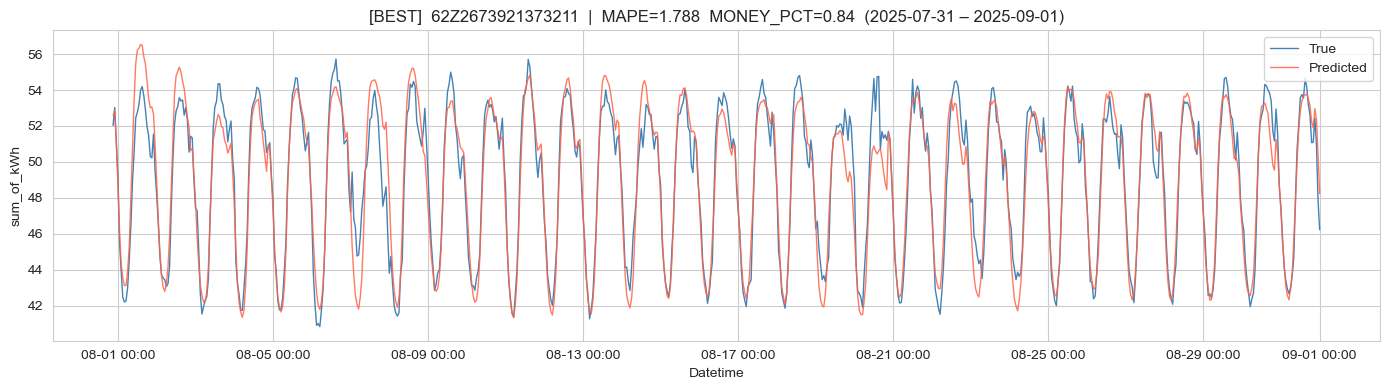

Worst station (MONEY_PCT): 62Z6035944504754


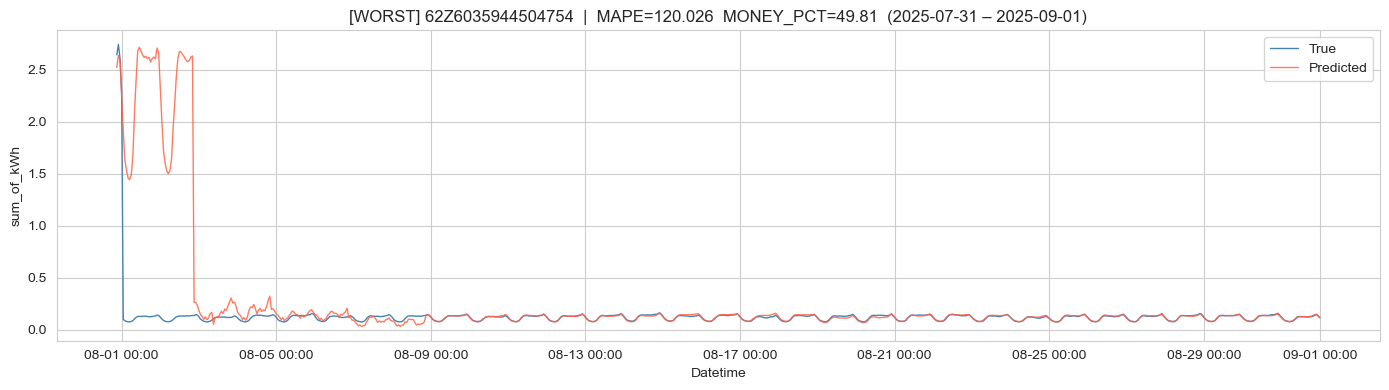

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]
print(f"Best  station (MONEY_PCT): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")
print(f"Worst station (MONEY_PCT): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")
